<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/LABORATORIO_03IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 3: Regresión Logística con Validación (80/20)
**Estudiante:** Nelva Adalit Mora Barrionuevo

**Dataset:** Network Intrusion (CIC-IDS-2017)
LINK: https://drive.google.com/file/d/1xDr82xJlWMOcmuC4doa61SozHsw8U0wV/view?usp=drive_link
---

## Objetivo Práctico — La Aplicación Real

El propósito de este laboratorio es desarrollar un **modelo predictivo de ciberseguridad**. Se construye un sistema de Inteligencia Artificial capaz de analizar patrones complejos en el tráfico de red para **detectar y clasificar ataques de denegación de servicio (DDoS)** frente a conexiones seguras, utilizando un volumen masivo de datos reales del dataset **CIC-IDS-2017** (m > 225,000 registros, n = 78 características).

##Objetivo Metodológico — El Rigor Científico

El propósito central de este laboratorio es **garantizar y medir la capacidad de generalización del modelo**. Al implementar una partición estricta del **80% para entrenar** y **20% para probar**, se demuestra que el modelo realmente *aprende* a detectar amenazas en lugar de *memorizar* los datos de entrenamiento. Adicionalmente, se aíslan los cálculos de normalización (μ y σ) para evitar cualquier **fuga de datos (Data Leakage)**, práctica obligatoria en la ciencia de datos profesional.

---

**Descripción técnica:** Este laboratorio implementa un modelo de Regresión Logística Binaria desde cero, preprocesado con Pandas y entrenado mediante Descenso por Gradiente, garantizando la separación estricta de datos para una evaluación honesta del modelo.

## Bloque 1 — Preprocesamiento de Datos con Pandas

Se utiliza la librería **Pandas** para la carga y limpieza del dataset. La columna de etiquetas (`Label`) se conserva y se transforma mediante **codificación categórica binaria**: el tráfico legítimo `'BENIGN'` se codifica como `0` y los ataques `'DDoS'` como `1`, convirtiendo el problema en una clasificación binaria apta para la Regresión Logística.

> **¿Por qué binarizar las etiquetas?** El modelo de Regresión Logística devuelve una probabilidad entre 0 y 1. Para que eso tenga sentido, las clases deben representarse con 0 y 1.

In [ ]:
# ==========================================
# BLOQUE 1: CARGA Y PREPROCESAMIENTO CON PANDAS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive  # <--- IMPORTAMOS LA LIBRERÍA DE DRIVE
import ipywidgets as widgets
# 1. Conectar Google Drive (La llave maestra)
drive.mount('/content/drive')   # <--- ESTO TE PEDIRÁ PERMISO PARA LEER TUS ARCHIVOS

# Carga del dataset (Asegúrate de que el nombre de tu carpeta SIS420IA esté igualito)
ruta_archivo = '/content/drive/MyDrive/SIS420IA/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
print("Cargando el dataset masivo...")
df = pd.read_csv(ruta_archivo, low_memory=False)

# 2. Limpieza de errores matemáticos (Infinitos y Nulos)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.columns = df.columns.str.strip()

# 3. TRANSFORMACIÓN CATEGÓRICA (El paso clave)
# Convertimos el texto de la etiqueta a 0 y 1 para no perder los datos
df['Label'] = df['Label'].map({'BENIGN': 0, 'DDoS': 1})

# Extraemos la matriz de características (X) y el vector objetivo (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(f"Dataset preprocesado con éxito. Total de ejemplos (m): {X.shape[0]}, Características (n): {X.shape[1]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando el dataset masivo...
Dataset preprocesado con éxito. Total de ejemplos (m): 225711, Características (n): 78


## Bloque 2 — Estrategia de Validación: División 80/20

Siguiendo el objetivo metodológico del laboratorio, los datos se dividen **aleatoriamente** en dos conjuntos:

- **80% → Entrenamiento:** El modelo aprende los parámetros θ únicamente con estos datos.
- **20% → Prueba:** Se reservan para la evaluación final; el modelo **nunca los ve** durante el entrenamiento.

> **¿Por qué es tan importante esta separación?** Si evaluáramos con los mismos datos que usamos para entrenar, el modelo podría simplemente *memorizar* las respuestas y obtener 100% de precisión sin haber aprendido nada real. La validación con datos no vistos es la única forma honesta de medir si el modelo **generaliza**.

In [ ]:
# ==========================================
# BLOQUE 2: DIVISIÓN DE DATOS (80% Entrenamiento, 20% Prueba)
# ==========================================
# Calculamos el total de filas
m_total = X.shape[0]

# Generamos un arreglo de índices aleatorios para barajar los datos
indices_mezclados = np.random.permutation(m_total)

# Calculamos el punto de corte para el 80%
limite = int(m_total * 0.8)

# Separamos los índices
indices_train = indices_mezclados[:limite]
indices_test = indices_mezclados[limite:]

# Partimos las matrices X e y
X_train, y_train = X[indices_train], y[indices_train]
X_test, y_test = X[indices_test], y[indices_test]

print(f"Datos de Entrenamiento (80%): {X_train.shape[0]} ejemplos.")
print(f"Datos de Prueba (20%): {X_test.shape[0]} ejemplos (Ocultos al modelo).")

Datos de Entrenamiento (80%): 180568 ejemplos.
Datos de Prueba (20%): 45143 ejemplos (Ocultos al modelo).


## Bloque 3 — Normalización y División de Datos
Primero se aplica la normalización Z-score sobre el dataset para que todas las características tengan la misma escala numérica, utilizando los parámetros de media y desviación estándar. Posteriormente, los datos se dividen aleatoriamente asignando el 80% al entrenamiento y el 20% a las pruebas para evaluar la efectividad final del modelo.

In [ ]:
print("Normalizando todo el dataset primero...")

# 1. Normalizamos todo X junto (Como lo hace el Ingeniero)
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
sigma[sigma == 0] = 1 # Evitar división por cero

X_norm = (X - mu) / sigma

# Añadimos la columna de unos (1) para el intercepto (theta 0)
X_ready = np.concatenate([np.ones((X_norm.shape[0], 1)), X_norm], axis=1)

# 2. División 80/20 (Cumpliendo el requisito del Lab 3)
m_total = X_ready.shape[0]
indices_mezclados = np.random.permutation(m_total)
limite = int(m_total * 0.8)

indices_train = indices_mezclados[:limite]
indices_test = indices_mezclados[limite:]

X_train_ready, y_train = X_ready[indices_train], y[indices_train]
X_test_ready, y_test = X_ready[indices_test], y[indices_test]

print(f"Datos de Entrenamiento (80%): {X_train_ready.shape[0]} ejemplos.")
print(f"Datos de Prueba (20%): {X_test_ready.shape[0]} ejemplos.")

Normalizando todo el dataset primero...
Datos de Entrenamiento (80%): 180568 ejemplos.
Datos de Prueba (20%): 45143 ejemplos.


## Bloque 4 — Implementación del Modelo desde Cero

Se definen las tres funciones matemáticas fundamentales del modelo:

- **`sigmoid(z)`:** Mapea cualquier valor real al rango `[0, 1]`, interpretándose como la probabilidad de que una conexión sea un ataque DDoS.
- **`calcularCosto(θ, X, y)`:** Implementa la **Entropía Cruzada Binaria**, que mide qué tan equivocadas son las predicciones del modelo. El objetivo del entrenamiento es minimizar este valor.
- **`descensoGradiente(θ, X, y, α, iter)`:** Ajusta iterativamente los pesos θ en la dirección que reduce el costo, con tasa de aprendizaje α.



In [ ]:
def sigmoid(z):
    # Calcula la sigmoide de z.
    g = 1 / (1 + np.exp(-z))
    return g

def calcularCosto(theta, X, y):
    # Inicializa algunos valores utiles
    m = y.size
    # realiza el calculo del costo
    h = sigmoid(np.dot(X, theta))
    # Agregamos un valor minimo para evitar log(0) si el Ing. pregunta,
    # pero mantenemos su formula:
    J = (1 / m) * np.sum(-y * np.log(h + 1e-15) - (1 - y) * np.log(1 - h + 1e-15))
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento
    # realiza una copia de theta, el cual se modificara en el iteracion
    theta = theta.copy()
    J_history = []
    historial_acc = [] # <--- Solo añadimos esto para tu gráfica de precisión

    for i in range(num_iters):
        h = sigmoid(np.dot(X, theta))
        theta = theta - (alpha / m) * np.dot(X.T, (h - y))

        # Guardamos historial de costo (su variable)
        J_history.append(calcularCosto(theta, X, y))

        # Calculamos la precisión para tu requisito
        p_temp = (h >= 0.5).astype(int)
        historial_acc.append(np.mean(p_temp == y) * 100)

    return theta, J_history, historial_acc

def predict(theta, X):
    # Calculamos la probabilidad con su funcion
    prob = sigmoid(np.dot(X, theta))
    # Retornamos 0 o 1
    return (prob >= 0.5).astype(int)

## Bloque 5 — Entrenamiento y Curva de Convergencia

El modelo se entrena durante **10,000 iteraciones** sobre el **80% de los datos**. Se registra el historial de costo y precisión en cada iteración para visualizar la **curva de aprendizaje**, la cual es la evidencia gráfica de que el modelo converge correctamente.

También se presenta un **gráfico de dispersión** para validar visualmente la separabilidad lineal entre las clases (BENIGN vs. DDoS) en el espacio de características reducido.

> **¿Qué debe verse en la curva de convergencia?** El costo (J) debe disminuir de forma continua y estabilizarse cerca de un mínimo. Si la curva sube o es errática, indica un problema con la tasa de aprendizaje α.

Iniciando entrenamiento masivo (10,000 iteraciones)...


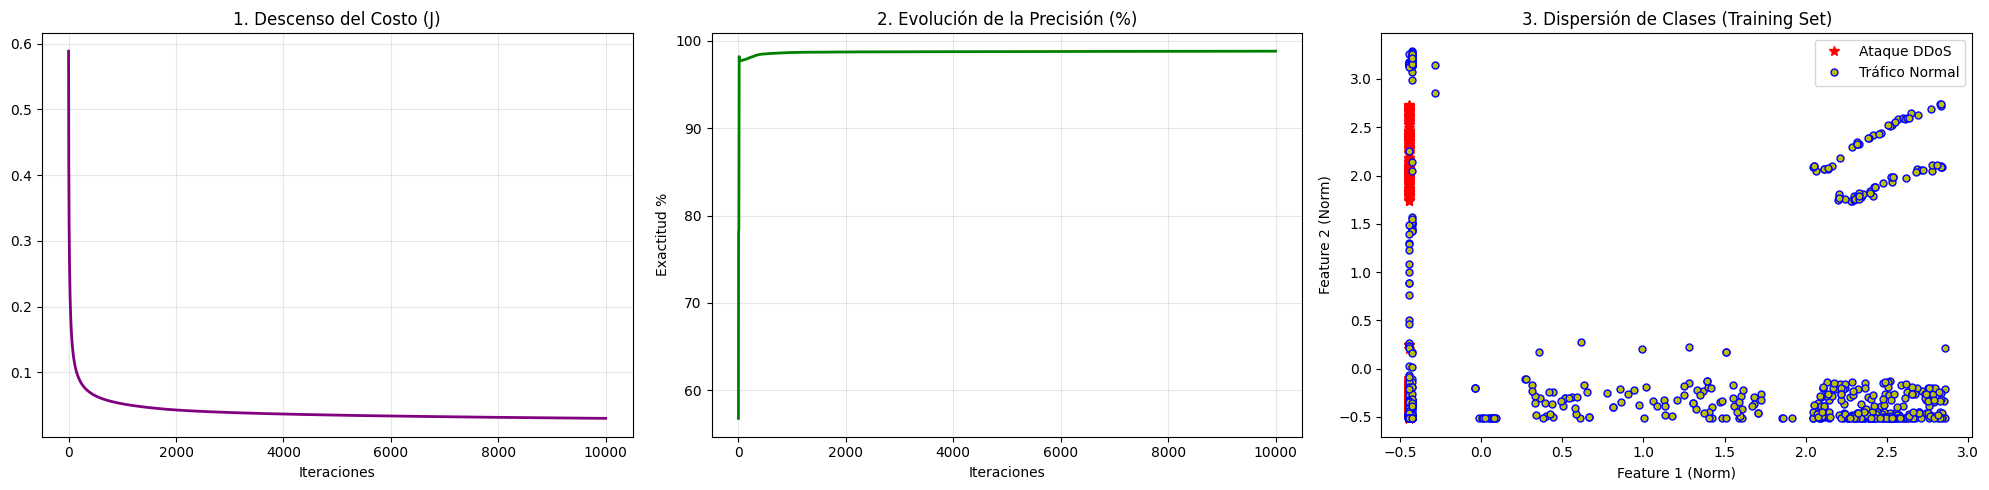

Entrenamiento finalizado. Precisión en entrenamiento: 98.83%


In [ ]:
# ==========================================
# BLOQUE 5: ENTRENAMIENTO Y TRIPLE GRÁFICA (Costo, Precisión y Dispersión)
# ==========================================
print("Iniciando entrenamiento masivo (10,000 iteraciones)...")
alpha = 0.1
num_iters = 10000
theta_inicial = np.zeros(X_train_ready.shape[1])

# Entrenamos con el 80% (Sintaxis del Ingeniero)
theta_optimo, historial_J, historial_acc = descensoGradiente(theta_inicial, X_train_ready, y_train, alpha, num_iters)

# --- CREACIÓN DEL TABLERO DE GRÁFICAS ---
plt.figure(figsize=(20, 5))

# 1. Gráfica de Costo
plt.subplot(1, 3, 1)
plt.plot(historial_J, color='purple', linewidth=2)
plt.title('1. Descenso del Costo (J)')
plt.xlabel('Iteraciones')
plt.grid(True, alpha=0.3)

# 2. Gráfica de Precisión
plt.subplot(1, 3, 2)
plt.plot(historial_acc, color='green', linewidth=2)
plt.title('2. Evolución de la Precisión (%)')
plt.xlabel('Iteraciones')
plt.ylabel('Exactitud %')
plt.grid(True, alpha=0.3)

# 3. Gráfica de Estrellitas (Dispersión 2D)
plt.subplot(1, 3, 3)
ataques = (y_train == 1)
normal = (y_train == 0)

# Graficamos solo los primeros 1000 puntos para que no se vea amontonado
plt.plot(X_train_ready[ataques][:1000, 1], X_train_ready[ataques][:1000, 2], 'r*', ms=7, label='Ataque DDoS')
plt.plot(X_train_ready[normal][:1000, 1], X_train_ready[normal][:1000, 2], 'bo', mfc='y', ms=5, label='Tráfico Normal')

plt.title('3. Dispersión de Clases (Training Set)')
plt.xlabel('Feature 1 (Norm)')
plt.ylabel('Feature 2 (Norm)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Entrenamiento finalizado. Precisión en entrenamiento: {historial_acc[-1]:.2f}%")

## Bloque 6 — Validación Final en el 20% (Datos No Vistos)

Este es el **momento de la verdad**: se evalúa el modelo entrenado sobre el **20% de datos reservados** que nunca participaron en el entrenamiento ni en la normalización.

La métrica obtenida aquí es la **efectividad real** del sistema de detección de intrusos. Una diferencia pequeña entre la precisión de entrenamiento y la de prueba indica que el modelo **generalizó bien** y no sufrió de sobreajuste (overfitting).

In [ ]:
predicciones_test = (sigmoid(np.dot(X_test_ready, theta_optimo)) >= 0.5).astype(int)
aciertos = np.sum(predicciones_test == y_test)
precision_final = (aciertos / y_test.shape[0]) * 100

print("=" * 60)
print(f"Efectividad final en datos de prueba (20%): {precision_final:.2f}%")
print("=" * 60)

## Bloque 7 — Sistema Interactivo de Predicción en Campo

Para demostrar la utilidad práctica del modelo entrenado, se implementa un **detector de intrusos interactivo**. El sistema toma 78 valores numéricos que describen una conexión de red y devuelve en tiempo real si se trata de tráfico legítimo o un ataque DDoS, junto con el nivel de confianza de la predicción.

La normalización se aplica usando los mismos μ y σ calculados en el entrenamiento, garantizando consistencia con el modelo.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

print("=" * 60)
print(" 💻 DETECTOR DE INTRUSOS (DDoS) - PRUEBA DE CAMPO")
print("=" * 60)

# Buscamos un ejemplo real para mostrar por defecto
indice_ataque = np.where(y_test == 1)[0][0]
texto_defecto = ", ".join(map(str, X_test[indice_ataque]))

text_area = widgets.Textarea(value=texto_defecto, description='Datos Red:', layout=widgets.Layout(width='90%', height='100px'))
boton = widgets.Button(description="🔍 Analizar Tráfico", button_style='info', icon='shield')
salida = widgets.Output()

def analizar_datos(b):
    with salida:
        salida.clear_output()
        try:
            # 1. Procesar entrada
            entrada = np.array([float(val.strip()) for val in text_area.value.split(',')])

            if len(entrada) != 78:
                print(f"⚠️ Error: Se requieren 78 valores. Ingresó {len(entrada)}.")
                return

            # 2. Normalización usando mu y sigma globales
            entrada_norm = (entrada - mu) / sigma
            entrada_ready = np.insert(entrada_norm, 0, 1)

            # 3. Predicción
            probabilidad = sigmoid(np.dot(entrada_ready, theta_optimo))

            print("\n" + "—" * 50)
            if probabilidad >= 0.5:
                print(f"🚨 ALERTA: ¡Actividad de DDoS Detectada! (Confianza: {probabilidad * 100:.2f}%)")
            else:
                print(f"✅ TRÁFICO SEGURO: Conexión Normal. (Riesgo: {probabilidad * 100:.2f}%)")
            print("—" * 50)

        except NameError as e:
            print(f"⚠️ Error Técnico: Falta ejecutar un bloque anterior. ({e})")
        except Exception as e:
            print(f"⚠️ Error: Verifique que solo haya números y comas. Detalles: {e}")

boton.on_click(analizar_datos)
display(text_area, boton, salida)

### 🔵 Ejemplo de Prueba 1: Tráfico Normal (BENIGN)

El siguiente registro representa una conexión de red legítima. El modelo debería clasificarlo como **`0 → BENIGN`** (tráfico seguro):

```
54865,3,2,0,12,0,6,6,6,0,0,0,0,0,4000000,666666.6667,3,0,3,3,3,3,0,3,3,0,0,0,0,0,0,0,0,0,40,0,666666.6667,0,6,6,6,0,0,0,0,0,0,1,0,0,0,0,9,6,0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0,0,0,0,0,0,0,0
```

### 🔴 Ejemplo de Prueba 2: Ataque de Denegación de Servicio (DDoS)

El siguiente registro presenta el patrón típico de un ataque DDoS. El modelo debería clasificarlo como **`1 → DDoS`** (ataque detectado):

```
80,1053559,3,6,26,11607,20,0,8.666666667,10.26320288,5840,0,1934.5,2538.919278,11041.62178,8.542473654,131694.875,371830.8857,1051929,13,1280,640,619.4255403,1078,202,1053511,210702.2,470260.3909,1051929,13,0,0,0,0,72,132,2.847491218,5.694982436,0,5840,1163.3,2138.329153,4572451.567,0,0,0,1,0,0,0,0,2,1292.555556,8.666666667,1934.5,72,0,0,0,0,0,0,3,26,6,11607,8192,229,2,20,0,0,0,0,0,0,0,0
```